In [1]:
import json
import os
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.special import betaln
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, TraceMeanField_ELBO
from numpyro.infer.util import init_to_value
from numpyro.infer.autoguide import AutoNormal # computes MAP to make family
from numpyro.optim import Adam, Adagrad
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.stats import beta, norm
from scipy.special import expit, logit

This script demonstrates why initialization sensitivity is something we are concerned about. We examine a bimodal beta and demonstrate that choice of intial values factors into which mode the VI algorithm finds.

In [2]:
# pdf functions
def beta_mixture_pdf(x, alpha_vec, beta_vec, mix_probs):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    comps = dist.Beta(alpha_vec, beta_vec)           # vectorized over K components
    log_pdf = comps.log_prob(x[:, None])             # [n_x, K]
    pdf = jnp.exp(log_pdf)                           # [n_x, K]
    return (pdf * mix_probs).sum(axis=1)             # [n_x]

def sigmoidnormal_pdf(x, mu, sigma):
    # y ~ Normal(mu, sigma), x = sigmoid(y)
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    y = jnp.log(x) - jnp.log1p(-x)                   # logit(x)
    norm = dist.Normal(mu, sigma)
    return jnp.exp(norm.log_prob(y)) / (x * (1 - x))

def normal_pdf(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

def beta_mixture_logit_pdf(x, alpha_vec, beta_vec, mix_probs):
    # X = logit(Theta), Theta ~ mixture on (0,1)
    theta = jax.nn.sigmoid(x)
    p_theta = beta_mixture_pdf(theta, alpha_vec, beta_vec, mix_probs)
    jac = theta * (1.0 - theta)                      # d/dx sigmoid(x)
    return p_theta * jac

In [3]:
# ---- Target distribution: *bimodal* Beta mixture on (0,1)
alpha_vec = jnp.array([20.0,  2.0])   
beta_vec  = jnp.array([ 2.0, 20.0])
mix_probs = jnp.array([0.5, 0.5])
n_samples = 0
y_data = jnp.array([])

# Initializations in unconstrained reals
# init_mus = [0.05, 0.08, 0.20, 0.80, 0.92, 0.95]
init_mus = [0.2, 0.92]

def model(y=None):
    components = dist.Beta(alpha_vec, beta_vec)         # vectorized over 2 comps
    mix = dist.MixtureSameFamily(
        mixing_distribution = dist.Categorical(probs=mix_probs),
        component_distribution = components
    )
    theta = numpyro.sample("theta", mix)
    if y is not None: numpyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)

optimizer = Adam(step_size=1e-2)
elbo = TraceMeanField_ELBO(num_particles=100)

posteriors = []   # will store (mu_uncon, sigma_uncon) for plotting

# Fit one AutoNormal guide per init, using init_to_value for theta
for i, mu0 in enumerate(init_mus):
    print(f"\nInit {i}: theta_init={mu0}")

    temp_guide = AutoNormal(model,
                            init_loc_fn=init_to_value(values={"theta": jnp.array(mu0)}))
    temp_svi = SVI(model, temp_guide, optimizer, elbo)

    svi_result = temp_svi.run(
        jax.random.PRNGKey(10 + i),
        50_000,
        y=y_data,
    )

    mu_uncon   = float(np.asarray(svi_result.params["theta_auto_loc"]))
    sigma_uncon = float(np.asarray(svi_result.params["theta_auto_scale"]))
    posteriors.append((mu_uncon, sigma_uncon))


Init 0: theta_init=0.2


  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 1/50000 [00:00<4:57:39,  2.80it/s]

  2%|▏         | 780/50000 [00:00<00:22, 2227.05it/s]

  3%|▎         | 1544/50000 [00:00<00:12, 3794.55it/s]

...

 95%|█████████▌| 47560/50000 [00:06<00:00, 5466.65it/s, init loss: 2.2923, avg. loss [45001-47500]: 0.7214]

 96%|█████████▋| 48206/50000 [00:06<00:00, 5719.89it/s, init loss: 2.2923, avg. loss [45001-47500]: 0.7214]

 98%|█████████▊| 48878/50000 [00:06<00:00, 5988.01it/s, init loss: 2.2923, avg. loss [45001-47500]: 0.7214]

 99%|█████████▉| 49501/50000 [00:07<00:00, 5715.08it/s, init loss: 2.2923, avg. loss [45001-47500]: 0.7214]

100%|██████████| 50000/50000 [00:07<00:00, 6976.87it/s, init loss: 2.2923, avg. loss [47501-50000]: 0.7209]

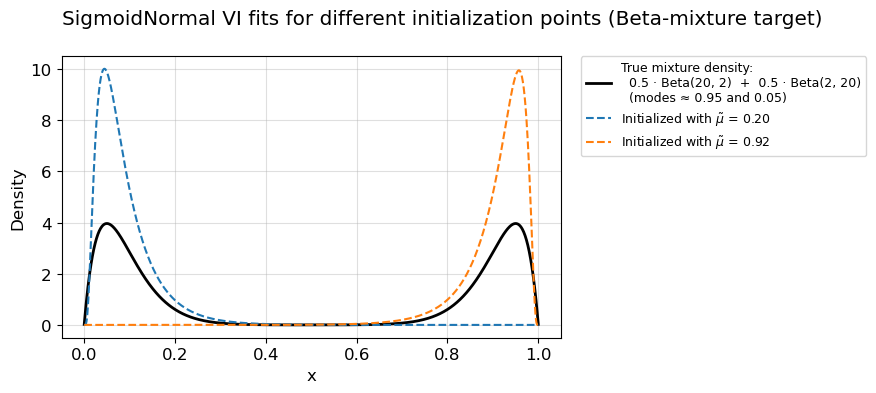

In [4]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 4))

xs = jnp.linspace(1e-4, 1 - 1e-4, 1000)

target_pdf = beta_mixture_pdf(xs, alpha_vec, beta_vec, mix_probs)

plt.plot(
    np.array(xs),
    np.array(target_pdf),
    label=(
        "True mixture density:\n"
        "  0.5 · Beta(20, 2)  +  0.5 · Beta(2, 20)\n"
        "  (modes ≈ 0.95 and 0.05)"
    ),
    linewidth=2,
    color='black'
)

# VI fits
for i, (mu_uncon, sigma_uncon) in enumerate(posteriors):
    mu0 = init_mus[i]
    label = r"Initialized with $\tilde{\mu}$ = " + f"{mu0:.2f}"
    plt.plot(
        np.array(xs),
        np.array(sigmoidnormal_pdf(xs, mu_uncon, sigma_uncon)),
        linestyle='--',
        linewidth=1.5,
        label=label
    )

plt.xlabel('x')
plt.ylabel('Density')
plt.grid(alpha=0.4)

# Legend fully outside on the right
plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=9
)

plt.suptitle('SigmoidNormal VI fits for different initialization points (Beta-mixture target)')
plt.tight_layout()
plt.show()

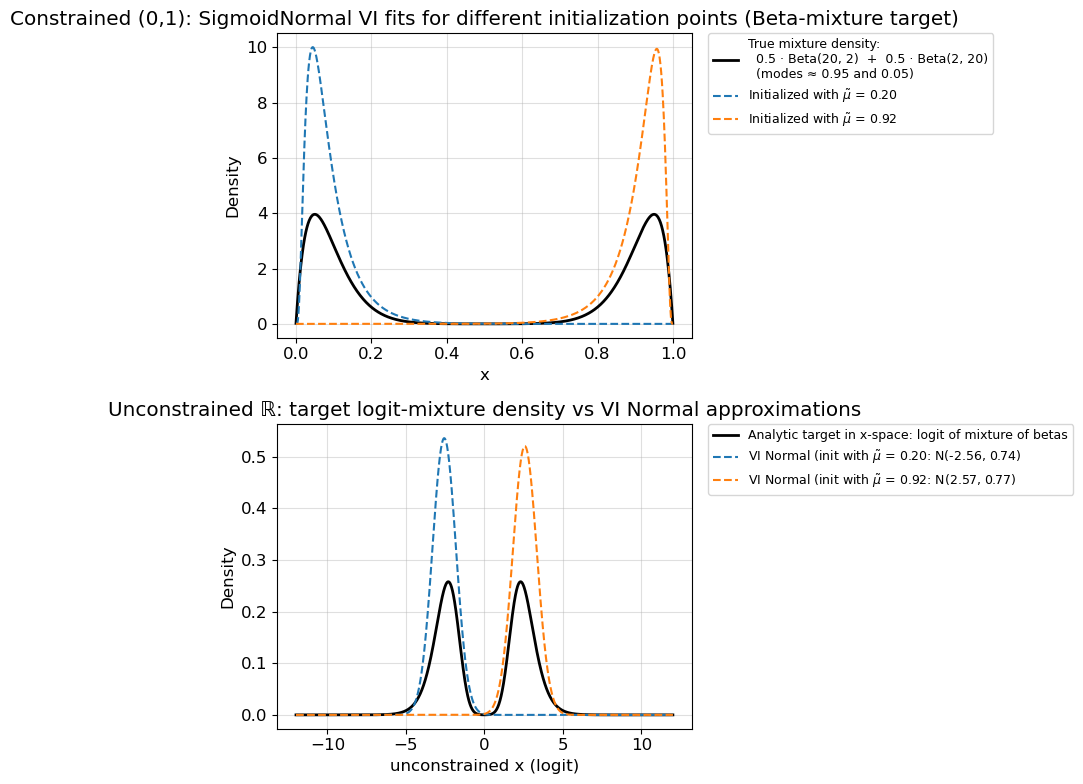

In [5]:
theta_grid = jnp.linspace(1e-4, 1 - 1e-4, 1000)
unconstrained_xs = jnp.linspace(-12.0, 12.0, 2000)  # covers logit of modes ~ logit(0.05)≈-2.94 and logit(0.95)≈+2.94
x_grid = unconstrained_xs

unconstrained_prior_pdf = beta_mixture_logit_pdf(unconstrained_xs, alpha_vec, beta_vec, mix_probs)

# ---- VI fits
vi_theta_pdfs = []
vi_x_pdfs = []
for i, (mu_uncon, sigma_uncon) in enumerate(posteriors):
    vi_theta_pdfs.append(sigmoidnormal_pdf(theta_grid, mu_uncon, sigma_uncon))
    vi_x_pdfs.append(jnp.exp(dist.Normal(mu_uncon, sigma_uncon).log_prob(x_grid)))

# ------------------------------------------------------------------
# Final figure: 2 vertical subplots
#   Top: constrained (as you had it)
#   Bottom: unconstrained reals with analytic pushforward of mixture + VI normals
# ------------------------------------------------------------------
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=False)

# ---------------- Top: constrained support (keep as-is style) ----------------
ax = axes[0]

xs = jnp.linspace(1e-4, 1 - 1e-4, 1000)

target_pdf = beta_mixture_pdf(xs, alpha_vec, beta_vec, mix_probs)

ax.plot(
    np.array(xs),
    np.array(target_pdf),
    label=(
        "True mixture density:\n"
        "  0.5 · Beta(20, 2)  +  0.5 · Beta(2, 20)\n"
        "  (modes ≈ 0.95 and 0.05)"
    ),
    linewidth=2,
    color='black'
)

# VI fits with improved labels
for i, (mu_uncon, sigma_uncon) in enumerate(posteriors):
    mu0 = init_mus[i]
    label = r"Initialized with $\tilde{\mu}$ = " + f"{mu0:.2f}"
    ax.plot(
        np.array(xs),
        np.array(sigmoidnormal_pdf(xs, mu_uncon, sigma_uncon)),
        linestyle='--',
        linewidth=1.5,
        label=label
    )

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.grid(alpha=0.4)

# Legend fully outside on the right
ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=9
)

ax.set_title('Constrained (0,1): SigmoidNormal VI fits for different initialization points (Beta-mixture target)')


# ---------------- Bottom: unconstrained real line ----------------
ax2 = axes[1]

ax2.plot(np.array(unconstrained_xs), np.array(unconstrained_prior_pdf),
         linewidth=2, color='black',
         label="Analytic target in x-space: logit of mixture of betas")

for i, (mu_uncon, sigma_uncon) in enumerate(posteriors):
    mu0 = init_mus[i]
    label = r"VI Normal (init with $\tilde{\mu}$ = " + f"{mu0:.2f}: N({mu_uncon:.2f}, {sigma_uncon:.2f})"
    ax2.plot(
        np.array(unconstrained_xs),
        np.array(normal_pdf(unconstrained_xs, mu_uncon, sigma_uncon)),
        linestyle='--',
        linewidth=1.5,
        label=label
    )


ax2.set_xlabel('unconstrained x (logit)')
ax2.set_ylabel('Density')
ax2.grid(alpha=0.4)
ax2.set_title('Unconstrained ℝ: target logit-mixture density vs VI Normal approximations')

ax2.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=9
)

plt.tight_layout()
plt.show()


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 1/100000 [00:00<6:59:00,  3.98it/s]

  1%|          | 831/100000 [00:00<00:32, 3008.68it/s]

  2%|▏         | 1709/100000 [00:00<00:19, 4974.61it/s]

  3%|▎         | 2609/100000 [00:00<00:15, 6292.57it/s]

...

 97%|█████████▋| 96566/100000 [00:11<00:00, 8942.44it/s, init loss: 3.4677, avg. loss [90001-95000]: 0.0460]

 97%|█████████▋| 97466/100000 [00:11<00:00, 8957.71it/s, init loss: 3.4677, avg. loss [90001-95000]: 0.0460]

 98%|█████████▊| 98362/100000 [00:11<00:00, 8952.33it/s, init loss: 3.4677, avg. loss [90001-95000]: 0.0460]

 99%|█████████▉| 99262/100000 [00:11<00:00, 8964.01it/s, init loss: 3.4677, avg. loss [90001-95000]: 0.0460]

100%|██████████| 100000/100000 [00:11<00:00, 8719.22it/s, init loss: 3.4677, avg. loss [95001-100000]: 0.0461]

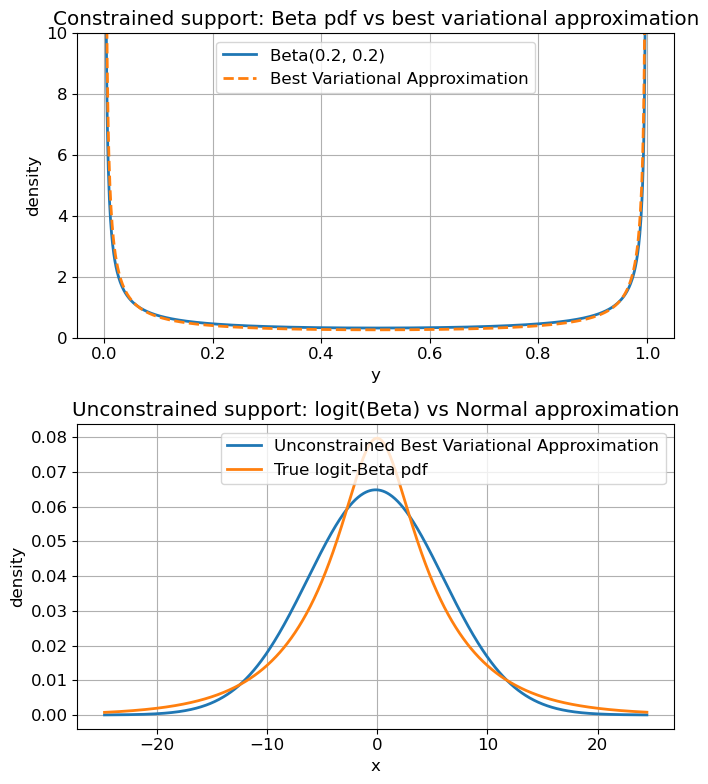

In [6]:


# Choose a Beta with heavy mass near 0 and 1
alpha_prior, beta_prior = 0.2, 0.2   # U-shaped


def beta_model(y=None):
    theta = numpyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
    if y is not None: numpyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)

optimizer = Adam(step_size=1e-2)
elbo = TraceMeanField_ELBO(num_particles=100)
guide = AutoNormal(beta_model)
svi = SVI(beta_model, guide, optimizer, elbo)
svi_result = svi.run(
    jax.random.PRNGKey(0),
    100_000,
    y=jnp.array([]))
unconstrained_posterior = [
        float(np.asarray(svi_result.params["theta_auto_loc"])),
        float(np.asarray(svi_result.params["theta_auto_scale"]))
]

# Grids for plotting
y_grid = np.linspace(1e-4, 1 - 1e-4, 1000)  # avoid exact 0 and 1
x_grid = np.linspace(unconstrained_posterior[0] - 4 * unconstrained_posterior[1], unconstrained_posterior[0] + 4 * unconstrained_posterior[1], 1000)

# Beta pdf on (0,1), sigmoid-normal induced by fitted normal on x
beta_pdf = beta.pdf(y_grid, alpha_prior, beta_prior)
sigmoid_normal_pdf = sigmoidnormal_pdf(y_grid, unconstrained_posterior[0], unconstrained_posterior[1])

# fitted normal pdf on x, logit-Beta pdf on x
normal_pdf_x = normal_pdf(x_grid, unconstrained_posterior[0], unconstrained_posterior[1])
y_from_x = expit(x_grid)
logit_beta_pdf_x = beta.pdf(y_from_x, alpha_prior, beta_prior) * (y_from_x * (1 - y_from_x))


fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=False)

# ---------- (1) Constrained Plot: Beta vs SigmoidNormal ----------
ax = axes[0]
ax.plot(y_grid, beta_pdf, label=f"Beta({alpha_prior}, {beta_prior})", linewidth=2)
ax.plot(y_grid, sigmoid_normal_pdf, "--",
        label="Best Variational Approximation", linewidth=2)
ax.set_xlabel("y")
ax.set_ylabel("density")
ax.set_title("Constrained support: Beta pdf vs best variational approximation")
ax.legend()
ax.set_ylim(0, 10)
ax.grid(True)

# ---------- (2) Unconstrained Plot: logit(Beta) vs Normal vs histogram of logit(Beta samples)----------
ax2 = axes[1]
ax2.plot(x_grid, normal_pdf_x, linewidth=2,
         label="Unconstrained Best Variational Approximation")
ax2.plot(x_grid, logit_beta_pdf_x, linewidth=2,
         label="True logit-Beta pdf") 
ax2.set_xlabel("x")
ax2.set_ylabel("density")
ax2.set_title("Unconstrained support: logit(Beta) vs Normal approximation")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


